In [1]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [4]:
# Step 2: Load Dataset
df = pd.read_csv(r"C:\Users\amans\Downloads\Energy_consumption_dataset.csv")
print("✅ Dataset Loaded Successfully!\n")
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

✅ Dataset Loaded Successfully!

Dataset Shape: (5000, 12)

First 5 Rows:


,Month,Hour,DayOfWeek,Holiday,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
0,1,0,Saturday,No,25.139433,43.431581,1565.693999,5,On,Off,2.774699,75.364373
1,1,1,Saturday,No,27.731651,54.225919,1411.064918,1,On,On,21.831384,83.401855
2,1,2,Saturday,No,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,78.270888
3,1,3,Saturday,No,20.080469,50.371637,1452.316318,1,Off,On,8.623447,56.519850
4,1,4,Saturday,No,23.097359,51.401421,1094.130359,9,On,Off,3.071969,70.811732


In [5]:
# Step 3: Basic Information
print("\n📋 Dataset Info:")
print(df.info())
print("\n🔍 Checking for Missing Values:")
print(df.isnull().sum())

# Fill missing numeric values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove duplicates (if any)
df.drop_duplicates(inplace=True)

print("\n✅ Data Cleaned Successfully!")


📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Month              5000 non-null   int64  
 1   Hour               5000 non-null   int64  
 2   DayOfWeek          5000 non-null   object 
 3   Holiday            5000 non-null   object 
 4   Temperature        5000 non-null   float64
 5   Humidity           5000 non-null   float64
 6   SquareFootage      5000 non-null   float64
 7   Occupancy          5000 non-null   int64  
 8   HVACUsage          5000 non-null   object 
 9   LightingUsage      5000 non-null   object 
 10  RenewableEnergy    5000 non-null   float64
 11  EnergyConsumption  5000 non-null   float64
dtypes: float64(5), int64(3), object(4)
memory usage: 468.9+ KB
None

🔍 Checking for Missing Values:
Month                0
Hour                 0
DayOfWeek            0
Holiday              0
Temperature

In [7]:
# Step 4: Exploratory Data Analysis (EDA)
print("\n📊 Statistical Summary:")
display(df.describe())




📊 Statistical Summary:


,Month,Hour,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,6.251200,11.556000,24.946823,45.478146,1507.403201,4.576000,15.201195,76.794919
std,3.588687,6.888306,3.041678,8.972690,293.147209,2.906185,9.157038,9.231573
min,1.000000,0.000000,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,3.000000,6.000000,22.453790,38.111104,1253.906598,2.000000,7.477928,70.419588
50%,6.000000,11.000000,24.831846,45.793124,1513.581105,5.000000,15.343830,76.696267
75%,9.000000,18.000000,27.427281,52.696651,1754.846457,7.000000,22.889997,83.246274
max,12.000000,23.000000,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

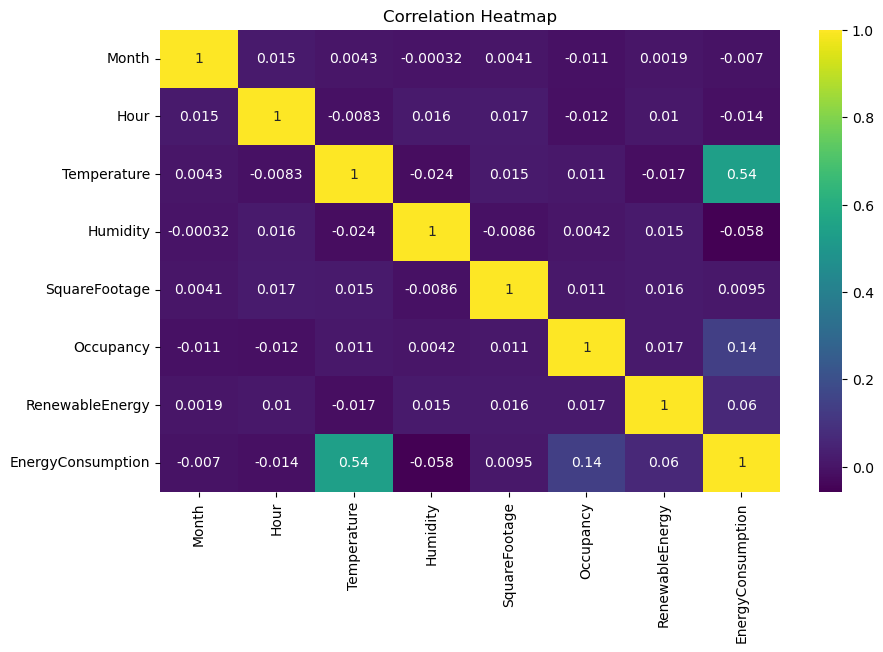

In [14]:

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Plot correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='viridis')
plt.title("Correlation Heatmap")
plt.show()


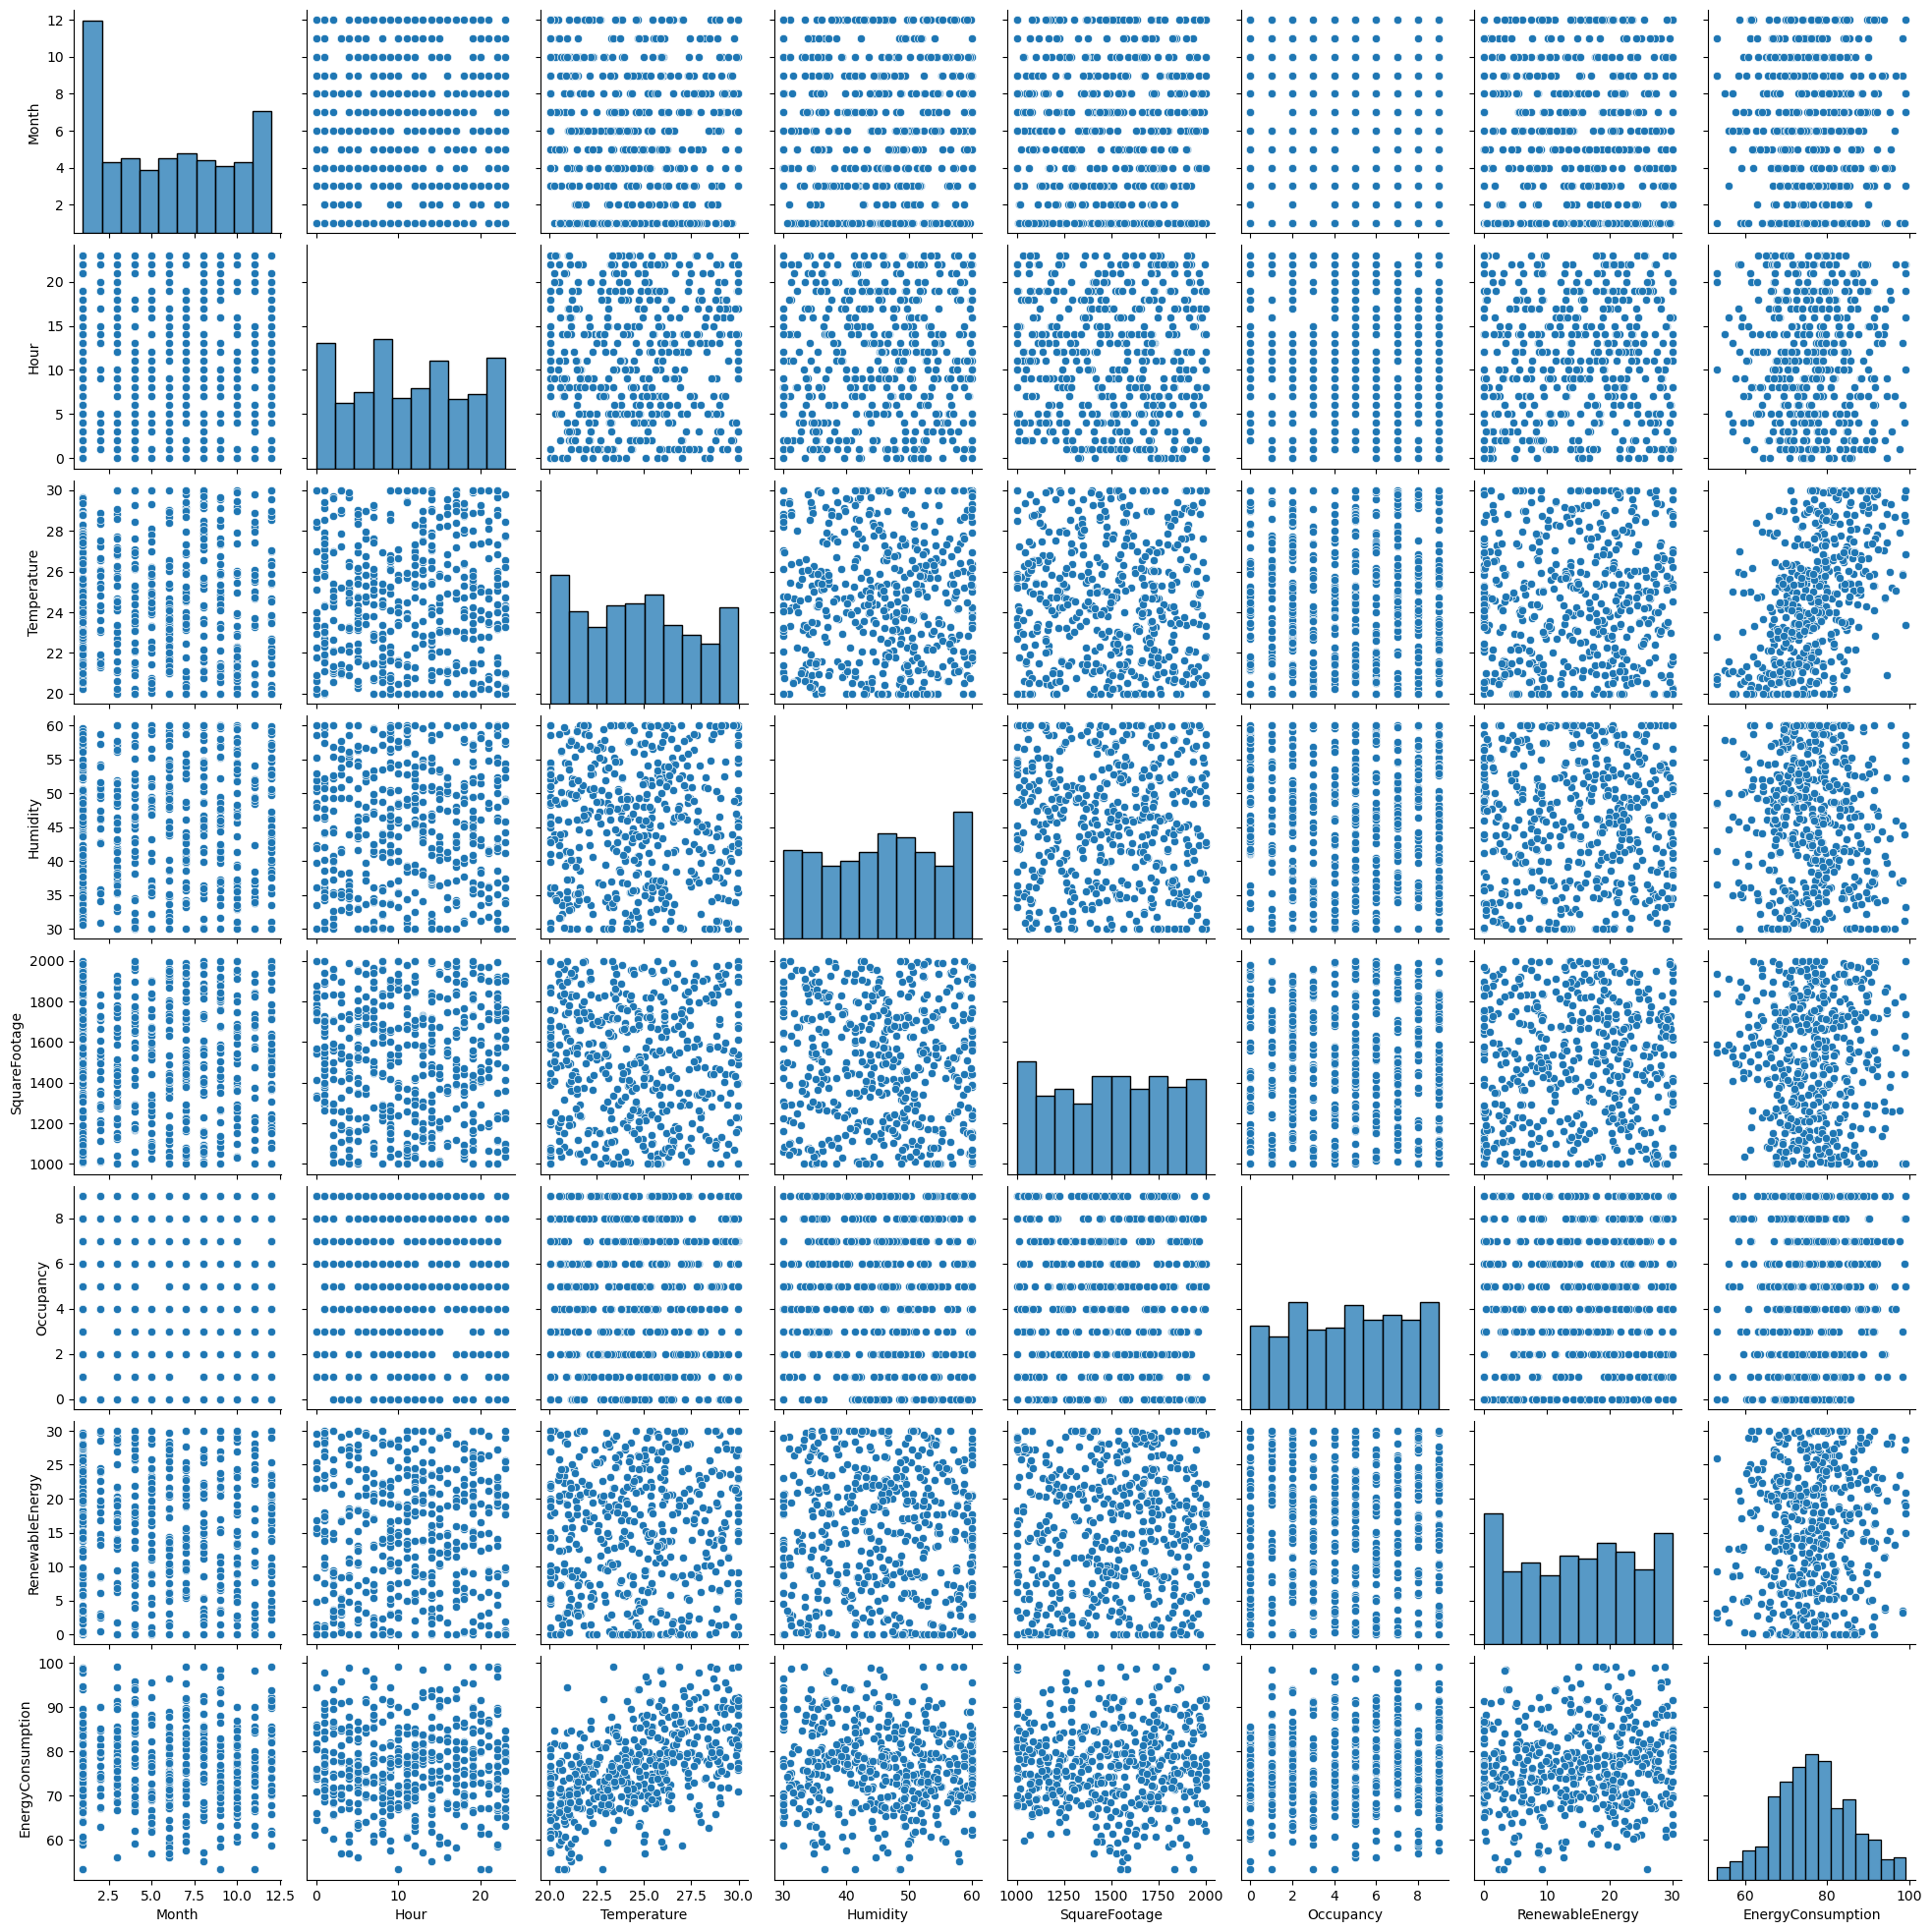

In [17]:
# Select numeric columns and drop NaNs
clean_df = df.select_dtypes(include='number').dropna()

# Limit rows if dataset is large
sample_df = clean_df.sample(n=500, random_state=42) if len(clean_df) > 500 else clean_df

# Plot pairplot
try:
    sns.pairplot(sample_df)
    plt.show()
except Exception as e:
    print("Pairplot skipped or failed:", e)


In [20]:
print(df.columns)


Index(['Month', 'Hour', 'DayOfWeek', 'Holiday', 'Temperature', 'Humidity',
       'SquareFootage', 'Occupancy', 'HVACUsage', 'LightingUsage',
       'RenewableEnergy', 'EnergyConsumption'],
      dtype='object')


In [26]:
# Auto-detect target column containing the word "energy"
target_col = [col for col in df.columns if "energy" in col.lower()][0]

print(f"✅ Target column detected: {target_col}")

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📦 Training Data: {X_train.shape}")
print(f"📦 Testing Data: {X_test.shape}")


✅ Target column detected: RenewableEnergy

📦 Training Data: (4000, 11)
📦 Testing Data: (1000, 11)


In [31]:

# ============================================================
# Step 6: Model Training
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n✅ Models Trained Successfully!")



✅ Models Trained Successfully!


In [32]:
# Step 7: Model Evaluation
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n📈 {model_name} Performance:")
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")



📈 Linear Regression Performance:
MAE : 7.94
MSE : 84.80
RMSE: 9.21
R² Score: 0.0009

📈 Random Forest Performance:
MAE : 7.84
MSE : 84.61
RMSE: 9.20
R² Score: 0.0033


<Figure size 800x500 with 0 Axes>

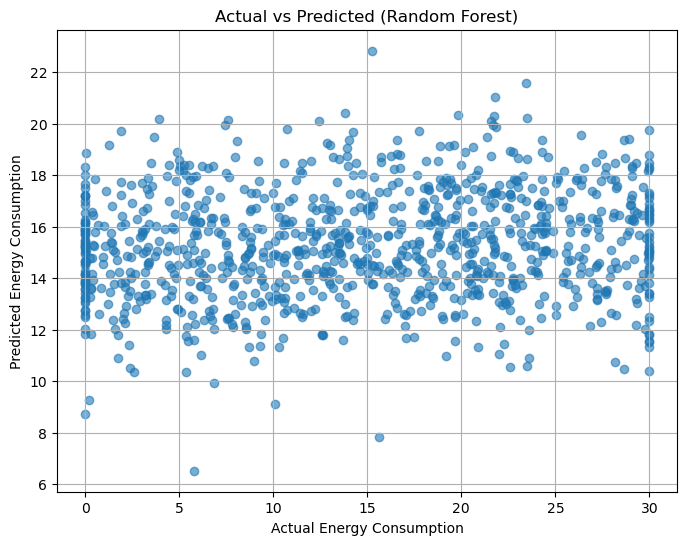

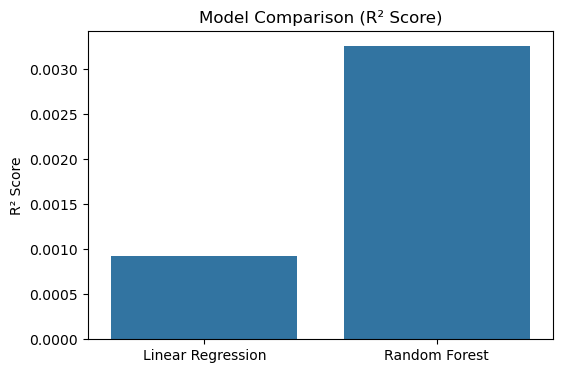

In [33]:
# Step 8: Visualization - Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted (Random Forest)")
plt.grid(True)
plt.show()

# Comparison of models by R2
models = ['Linear Regression', 'Random Forest']
r2_scores = [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf)]
plt.figure(figsize=(6,4))
sns.barplot(x=models, y=r2_scores)
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()


In [34]:
# Step 9: Predict New Values
print("\n🔮 Predicting for a New Input Row:")
new_data = pd.DataFrame([X_test.iloc[0]])  # sample row from test set
display(new_data)
predicted_value = rf.predict(new_data)[0]
print(f"\n⚡ Predicted Energy Consumption: {predicted_value:.2f} units")



🔮 Predicting for a New Input Row:


,Month,Hour,Temperature,Humidity,SquareFootage,Occupancy,EnergyConsumption,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,Holiday_Yes,HVACUsage_On,LightingUsage_On
1501,4,5,23.115059,30.015975,1424.678701,7,84.778571,False,False,False,True,False,False,True,False,False



⚡ Predicted Energy Consumption: 11.31 units


In [35]:
# Step 10: Save Model
joblib.dump(rf, "energy_consumption_model.pkl")
print("\n💾 Model saved successfully as 'energy_consumption_model.pkl'!")



💾 Model saved successfully as 'energy_consumption_model.pkl'!
